In [1]:
from google.colab import drive
drive.mount('/content/drive')


Mounted at /content/drive


In [2]:
!pip install -q numpy matplotlib opencv-python tqdm


In [3]:
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm


## Data Exploration

In this section, the dataset structure is explored and all SAR image files are identified.  
This step helps estimate dataset size and understand how the data is organized.


In [4]:
BASE_PATH = "/content/drive/MyDrive/Oil_Spill_Project"

FINAL_DATASET_PATH = (
    "/content/drive/MyDrive/Oil_Spill_Project/Dataset/"
    "Module_1_Data_Collection- Piyush Ranjan/Dataset"
)

PREPROCESS_OUTPUT = os.path.join(
    BASE_PATH,
    "Module_2_Data_Exploration-Preprocessing/preprocessed_data"
)

os.makedirs(PREPROCESS_OUTPUT, exist_ok=True)


In [6]:
print("Top-level dataset contents:")
print(os.listdir(FINAL_DATASET_PATH))


Top-level dataset contents:
['README.md.txt', 'Dataset_Description.txt.txt', 'Dataset_Source.txt.txt', 'Sentinel_SAR_Part 3', 'Sentinel_SAR_Part 1', 'Sentinel_SAR_Part 2']


In [7]:
image_paths = []

for part in os.listdir(FINAL_DATASET_PATH):
    part_path = os.path.join(FINAL_DATASET_PATH, part)

    if os.path.isdir(part_path) and "Sentinel" in part:
        for root, _, files in os.walk(part_path):
            for file in files:
                if file.lower().endswith(('.png', '.jpg', '.jpeg', '.tif')):
                    image_paths.append(os.path.join(root, file))

print("Total image files found:", len(image_paths))


Total image files found: 6039


In [8]:
print("Validation strategy: unreadable images will be skipped during preprocessing.")


Validation strategy: unreadable images will be skipped during preprocessing.


## Sample Visualization

Random SAR image samples are visualized to verify data integrity and understand SAR texture characteristics such as speckle noise.


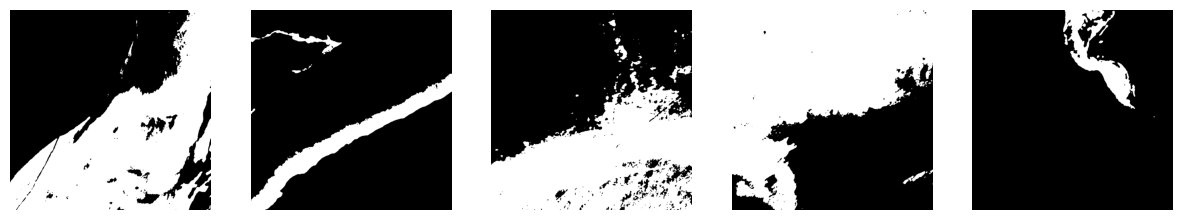

In [9]:
import random

# Pick readable images only
sample_imgs = []

for path in image_paths:
    img = cv2.imread(path, cv2.IMREAD_GRAYSCALE)
    if img is not None:
        sample_imgs.append(img)
    if len(sample_imgs) == 5:
        break

plt.figure(figsize=(15,5))
for i, img in enumerate(sample_imgs):
    plt.subplot(1,5,i+1)
    plt.imshow(img, cmap='gray')
    plt.axis("off")
plt.show()


## SAR Image Characteristics

SAR images differ from optical images.  
Pixel intensities represent radar backscatter and include inherent speckle noise.  
This section analyzes pixel intensity distribution and applies basic speckle noise reduction.


In [10]:
img = sample_imgs[0]

print("Image Shape :", img.shape)
print("Data Type   :", img.dtype)
print("Min Value   :", img.min())
print("Max Value   :", img.max())


Image Shape : (2048, 2048)
Data Type   : uint8
Min Value   : 0
Max Value   : 1


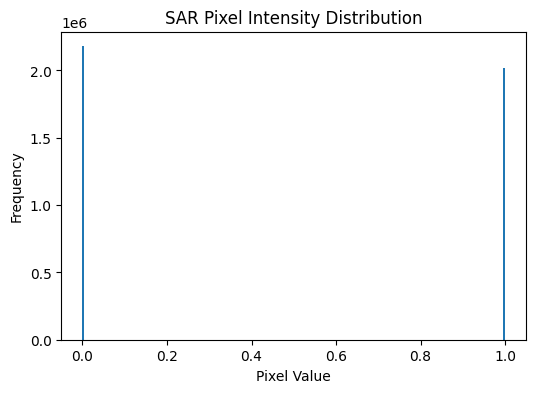

In [11]:
plt.figure(figsize=(6,4))
plt.hist(img.flatten(), bins=256)
plt.title("SAR Pixel Intensity Distribution")
plt.xlabel("Pixel Value")
plt.ylabel("Frequency")
plt.show()


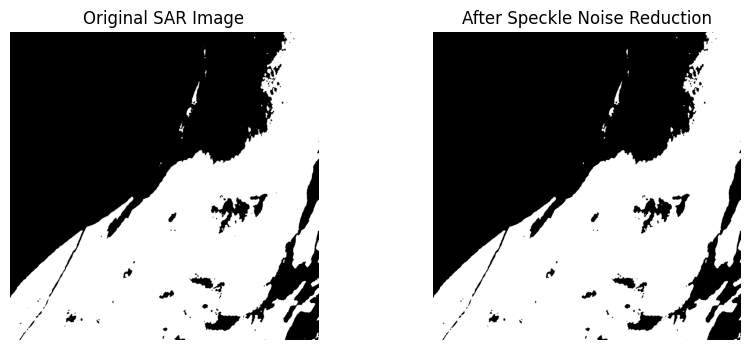

In [12]:
denoised_img = cv2.medianBlur(img, 5)

plt.figure(figsize=(10,4))
plt.subplot(1,2,1)
plt.title("Original SAR Image")
plt.imshow(img, cmap='gray')
plt.axis("off")

plt.subplot(1,2,2)
plt.title("After Speckle Noise Reduction")
plt.imshow(denoised_img, cmap='gray')
plt.axis("off")

plt.show()


## Preprocessing Pipeline

This section applies the final preprocessing pipeline to prepare training-ready data.  
All images are denoised, resized to a fixed resolution, normalized, and saved in a consistent format.


In [13]:
IMG_SIZE = 256
processed_count = 0

for path in tqdm(image_paths, desc="Preprocessing SAR Images"):
    img = cv2.imread(path, cv2.IMREAD_GRAYSCALE)

    if img is None:
        continue

    # Speckle noise reduction
    img = cv2.medianBlur(img, 5)

    # Resize
    img = cv2.resize(img, (IMG_SIZE, IMG_SIZE))

    # Normalize
    img = img.astype(np.float32) / 255.0

    # Save
    np.save(
        os.path.join(PREPROCESS_OUTPUT, f"image_{processed_count}.npy"),
        img
    )

    processed_count += 1

print("Total preprocessed images:", processed_count)


Preprocessing SAR Images: 100%|██████████| 6039/6039 [1:39:14<00:00,  1.01it/s]

Total preprocessed images: 3020


In [14]:
files = os.listdir(PREPROCESS_OUTPUT)

sample = np.load(os.path.join(PREPROCESS_OUTPUT, files[0]))

print("Total Preprocessed Files :", len(files))
print("Final Image Shape        :", sample.shape)
print("Min Pixel Value          :", sample.min())
print("Max Pixel Value          :", sample.max())


Total Preprocessed Files : 3020
Final Image Shape        : (256, 256)
Min Pixel Value          : 0.0
Max Pixel Value          : 0.003921569


## Preprocessing Pipeline

This section applies the final preprocessing pipeline to prepare training-ready data.  
All images are denoised, resized to a fixed resolution, normalized, and saved in a consistent format.


In [15]:
print("📊 DATA EXPLORATION & PREPROCESSING SUMMARY")
print("-"*45)
print("Raw images scanned        :", len(image_paths))
print("Final training images     :", len(files))
print("Image size                : 256 x 256")
print("Image type                : Grayscale SAR")
print("Speckle noise reduction   : Median Filter")
print("Normalization             : [0, 1]")
print("Labels / Masks available  : ❌ Not provided")


📊 DATA EXPLORATION & PREPROCESSING SUMMARY
---------------------------------------------
Raw images scanned        : 6039
Final training images     : 3020
Image size                : 256 x 256
Image type                : Grayscale SAR
Speckle noise reduction   : Median Filter
Normalization             : [0, 1]
Labels / Masks available  : ❌ Not provided
